In [1]:
# cil imports
from cil.framework import ImageData, ImageGeometry
from cil.framework import AcquisitionGeometry, AcquisitionData

from cil.plugins.astra.operators import ProjectionOperator

from cil.utilities.display import show2D

# External imports
from phantominator import shepp_logan
import numpy as np
from scipy.linalg import svd
import matplotlib.pyplot as plt

from cil.optimisation.functions import L1Norm, LeastSquares, TotalVariation, L2NormSquared


## Setting defaults and finding A from phantom data

In [2]:
# number of pixels and angles
n_pixels = 10
n_angles = 10

# other input
cmap = 'rainbow'
device = 'cpu'

In [3]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)


# Setup acquisition geometry
# with sufficient number of projections
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)
size_phantom = phantom.shape

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


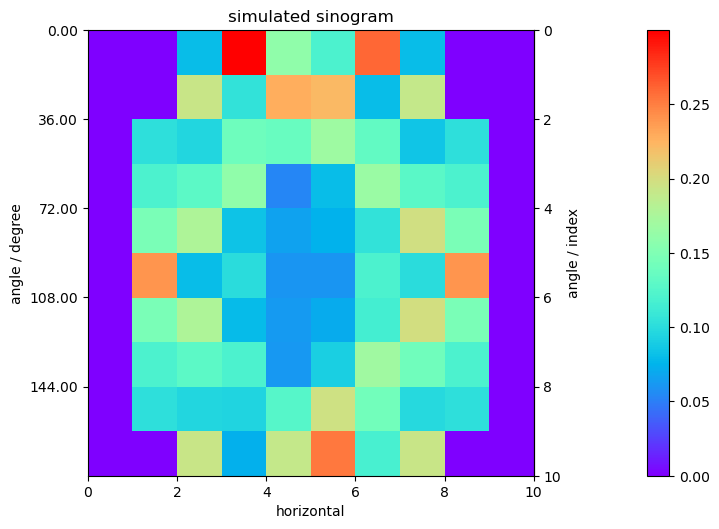

In [4]:
# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

# Visualise data
show2D(sino, 'simulated sinogram', cmap=cmap, size=(10,10), origin='upper-left')

# Create A and find singular values

In [5]:
zero_image = ig.allocate(0.0)
size_sino = sino.size # size sino = n_angles * n_pixels
total_pixels = n_pixels ** 2

# Columns of A represent the pixels, rows of A the detected data (number of angles=size sino)
A_radon = np.zeros((size_sino, total_pixels))

pixel_index = 0

# Run over all pixels, make them equal 1, one by
for pixel_number_y in range(n_pixels):
    for pixel_number_x in range(n_pixels):
        zero_image.as_array()[pixel_number_y, pixel_number_x] = 1.0

        # We compute A by considering AI
        sinogram_basis = A.direct(zero_image).as_array()

        A_radon[:, pixel_index] = sinogram_basis.reshape(size_sino,)

        zero_image.as_array()[pixel_number_y, pixel_number_x] = 0.0
        pixel_index = pixel_index + 1

print('The size of A_radon is', A_radon.shape)

The size of A_radon is (100, 100)


In [6]:
def mean_ATA(A, n_pixels):
    """
    A is a ProjectionOperator
    """
    two_norm = L2NormSquared()
    get_ig = A.domain_geometry()

    sum = 0
    n = 500
    for k in range(n):

        # generate random entries
        xk = np.random.normal(0, 1, (n_pixels, n_pixels))

        # put random entries in class <DataContainer>
        xk_datacon = get_ig.allocate()
        xk_datacon.fill(xk)

        # compute 
        yk = A.direct(xk_datacon)
        sum += two_norm(yk)
    
    final = (1/n)*sum
    return final

test = mean_ATA(A, n_pixels)
print(test)

9.104037699699402


In [7]:
exact_norm = np.linalg.norm(A_radon)**2
print(exact_norm)

8.930061761873315


c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


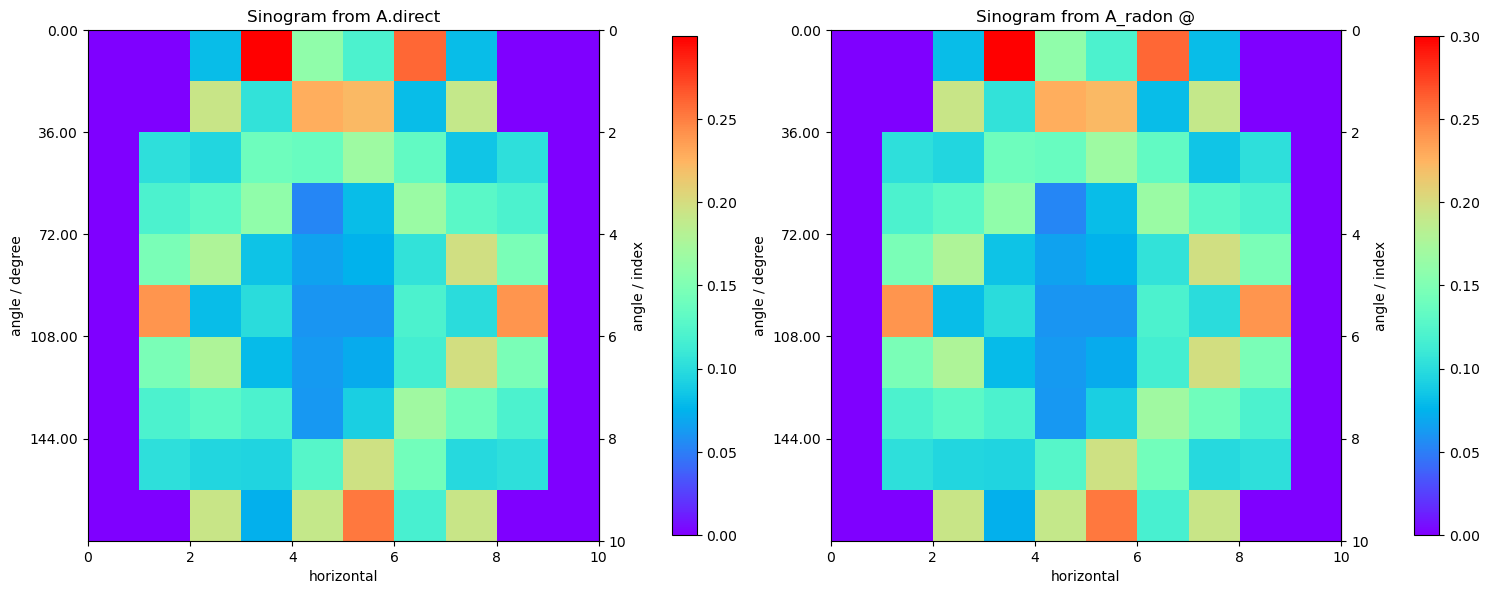

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


7.234404427720182e-08

In [8]:
# Au = b, with b the sinogram, A the computed radonmatrix and u the phantom
sino_new = A_radon @ phantom.as_array().reshape(total_pixels,)
sino_new = AcquisitionData(sino_new.reshape(sino.shape), geometry=ag) # not sure what this does


# Visualise data
show2D([sino, sino_new], ['Sinogram from A.direct', 'Sinogram from A_radon @'], \
       cmap=cmap, num_cols=3, size=(15,10), origin='upper-left')

# error computation
diff = sino-sino_new
diff.norm()

Computing singular values of the A radon matrix

In [9]:
sing_values = svd(A_radon, compute_uv=False)
sing_values /= sing_values[0]

<class 'numpy.ndarray'>
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100.]
100


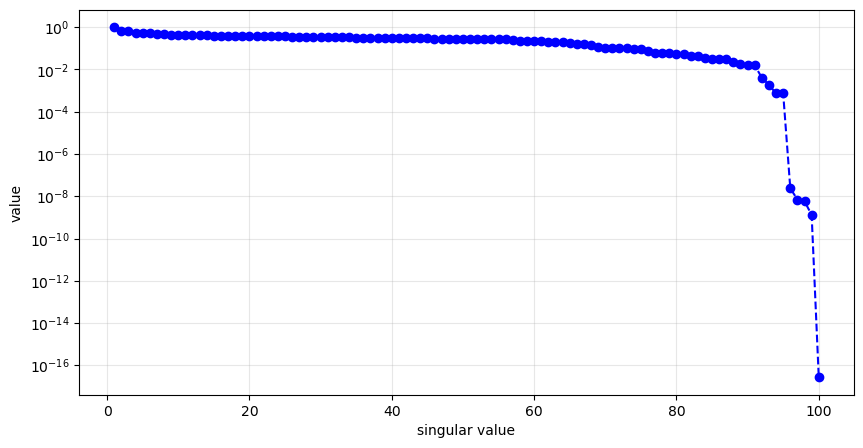

In [10]:
print(type(sing_values))
length = sing_values.size
x = np.linspace(1, length, length)
print(x)
print(length)

plt.figure(figsize=(10,5))
#plt.title(f'Singular values of A_radon with {n_angles} angles and {n_pixels} pixels')
plt.grid(alpha = 0.3)
plt.ylabel('value')
plt.xlabel('singular value')
plt.semilogy(x, sing_values, '--bo')
#plt.ylim(1e-10, 15)

## Doing it for more cases

In [11]:
def radon_A(n_angles, n_pixels):

    # Setup acquisition geometry
    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # with sufficient number of projections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    # Creating pojection operator
    proj_operator = ProjectionOperator(ig, ag, device)

    zero_image = ig.allocate(0.0)
    size_sino = n_angles*n_pixels 
    total_pixels = n_pixels ** 2

    # Columns of A represent the pixels, rows of A the detected data (number of angles=size sino)
    A_radon = np.zeros((size_sino, total_pixels))

    pixel_index = 0

    # Run over all pixels, make them equal 1, one by
    for pixel_number_y in range(n_pixels):
        for pixel_number_x in range(n_pixels):
            zero_image.as_array()[pixel_number_y, pixel_number_x] = 1.0

            # We compute A by considering AI
            sinogram_basis = proj_operator.direct(zero_image).as_array()

            A_radon[:, pixel_index] = sinogram_basis.reshape(size_sino,)

            zero_image.as_array()[pixel_number_y, pixel_number_x] = 0.0
            pixel_index = pixel_index + 1

    return A_radon

def compute_cond(n_angles, n_pixels):
    A_radon = radon_A(n_angles, n_pixels)
    print(np.shape(A_radon))
    sing_vals = svd(A_radon, compute_uv=False)

    cond_number = sing_vals[0]/sing_vals[-1]
    cond_number_ill = sing_vals[0]/sing_vals[-2]

    sing_vals /= sing_vals[0]

    return cond_number, sing_vals, cond_number_ill

(1000, 400)
(2000, 1600)
(3000, 3600)
(4000, 6400)
(5000, 10000)


(1e-09, 5)

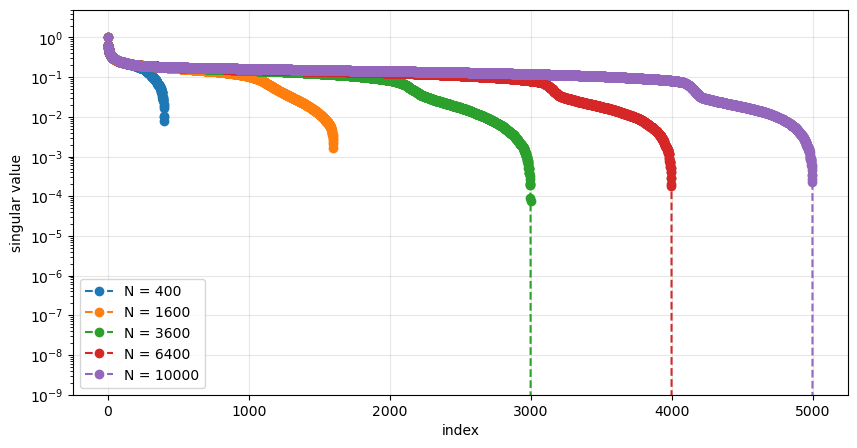

In [15]:
n_angles = 50

plt.figure(figsize=(10,5))
cond_number_array = []
cond_number_ill_array = []
for n_pixels in [20, 40, 60, 80, 100]:
    cond_number, sing_vals, cond_number_ill = compute_cond(n_angles, n_pixels)

    length = sing_vals.size
    x = np.linspace(1, length, length)
    plt.semilogy(x, sing_vals, '--o', label=f'N = {n_pixels**2}')
    
    cond_number_array.append(cond_number)
    cond_number_ill_array.append(cond_number_ill)

plt.ylabel('singular value')
plt.grid(alpha = 0.3)
plt.legend()
plt.xlabel('index')
plt.ylim(1e-9, 5)

ValueError: x and y must have same first dimension, but have shapes (6,) and (5,)

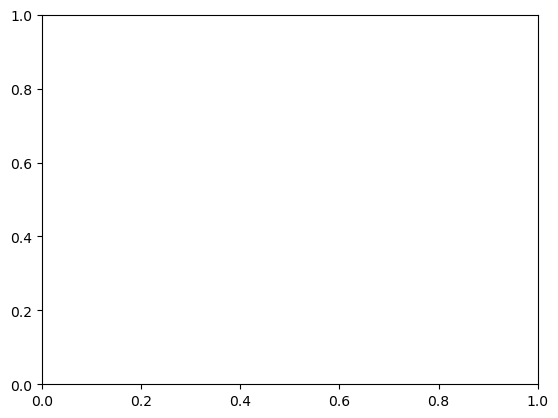

In [13]:
plt.figure()
plt.plot([20, 30, 40, 50, 60, 70], cond_number_array, '--o')
plt.ylabel('condition number')
plt.xlabel('number of pixels')
plt.grid(alpha = 0.3)

0.8750170352833512 1.921416677847966e-16


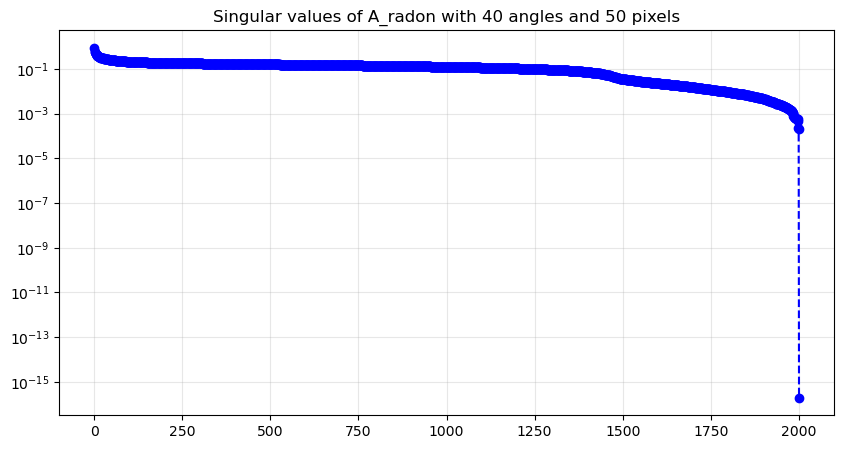

In [ ]:
n_angles = 40
n_pixels = 50

sing_vals = compute_cond(n_angles, n_pixels)[1]
length = sing_vals.size
x = np.linspace(1, length, length)
print(sing_vals[0], sing_vals[-1])

plt.figure(figsize=(10,5))
plt.title(f'Singular values of A_radon with {n_angles} angles and {n_pixels} pixels')
plt.grid(alpha =0.3)
plt.semilogy(x, sing_vals, '--bo')

iteration 0
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9


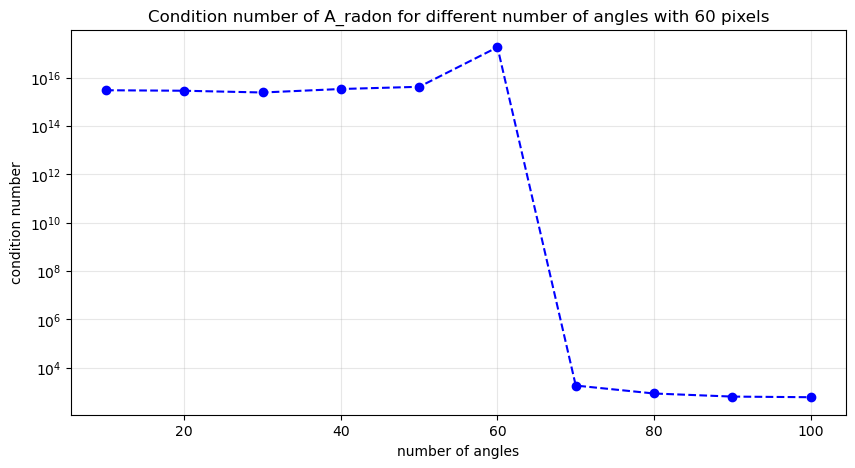

In [ ]:
n_angles = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
pixels = 60
cond_number = []
i = 0
for theta in n_angles: 
    cond_number.append(compute_cond(theta, pixels)[0])
    print(f'iteration {i}')
    i += 1

plt.figure(figsize=(10,5))
plt.semilogy(n_angles, cond_number, '--bo')
plt.xlabel('number of angles')
plt.ylabel('condition number')
plt.title(f'Condition number of A_radon for different number of angles with {pixels} pixels')
plt.grid(alpha=0.3)
